In [20]:
# ===============================
# Helcim Take Home Technical Challenge
# Part 2: Proof of Concept
# Step 2: Feature Engineering & Modeling
# ===============================

# Author: Shelly Resurreccion
# Purpose: This script contains the code for feature engineering and modeling for the Helcim take home technical challenge.

---
### 1.0 Set Up

In [21]:
# ===============================
# Imports:
# ===============================
# --- Standard library ---
import sys
import os
import warnings

# --- Data handling ---
import pandas as pd
import numpy as np

# --- Statistical tests ---
from scipy.stats import chi2_contingency, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Preprocessing ---
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# --- Modeling ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Warnings ---
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)


In [22]:
# ===============================
# Functions:
# ===============================
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from scripts.data_i_o.read_csv import read_csv
from scripts.ml_classification.logistical_regression import logistic_regression_classifier
from scripts.ml_classification.random_forest import random_forest_classifier
from scripts.ml_classification.gradient_boosting import gradient_boosting_classifier
from scripts.ml_classification.ordinal_regression import ordinal_logistic_regression_classifier, ordinal_class_weighted_classifier

---
### 2.0 Load Data and Review Values

In [23]:
# ===============================
# Load Data:
# ===============================
df = read_csv("../data/transformed_data.csv")

# Review data types and missing values
print("\n" + "="*60)
print("Data Types and Missing Values Review")
print("="*60)
print(df.info())

# Review unique values in the target column
print("\n" + "="*60)
print("Target Column Review")
print("="*60)
df["Severity"].unique()
df["Severity"].value_counts()


Data Types and Missing Values Review
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246404 entries, 0 to 246403
Data columns (total 52 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     246404 non-null  object 
 1   Source                 246404 non-null  object 
 2   Severity               246404 non-null  int64  
 3   Start_Time             246404 non-null  object 
 4   End_Time               246404 non-null  object 
 5   Start_Lat              246404 non-null  float64
 6   Start_Lng              246404 non-null  float64
 7   End_Lat                246404 non-null  float64
 8   End_Lng                246404 non-null  float64
 9   Distance(mi)           246404 non-null  float64
 10  Description            246404 non-null  object 
 11  Street                 246404 non-null  object 
 12  City                   246404 non-null  object 
 13  County                 246404 non-null  object 
 14

Severity
2    239344
4      7060
Name: count, dtype: int64

In [24]:
# Target variable
y = df['Severity']  # Ordinal target (e.g., 1,2,3,4,5)
X = df.drop(columns=['Severity'])

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

X_numeric = X[numeric_features]
X_categorical = X[categorical_features]

---

### 3.0 Feature Selection

**Methods Used**

A combination of complementary statistical techniques was applied to assess feature relevance from multiple perspectives:
1. Chi-Square Test of Independence (Categorical & Discretized Features): Used to evaluate whether individual features were statistically associated with accident severity. Features with very small p-values were considered strongly associated with the target.
2. Spearman Rank Correlation: Applied to numeric features to measure monotonic relationships with the ordinal target variable. Spearman correlation was chosen over Pearson correlation due to its suitability for ordinal outcomes and non-linear relationships.
3. ANOVA (Analysis of Variance): Used to determine whether the distribution of numeric features differed significantly across severity levels. Features with low p-values were interpreted as having meaningful variation across severity categories.
4. Variance Inflation Factor (VIF): Used to assess multicollinearity among numeric predictors. Extremely high VIF values were flagged as potential sources of coefficient instability in ordinal regression models.

**Key Takeaways**

- Many numeric features showed strong statistical significance (p ≪ 0.05) in both ANOVA and chi-square tests, indicating meaningful associations with accident severity—even when rank correlations were relatively small.
- Low Spearman correlation coefficients (< 0.1) did not invalidate feature usefulness, as ordinal outcomes often exhibit weak monotonic relationships despite being statistically significant.
- Geospatial features (latitude and longitude) exhibited extreme multicollinearity (very high VIF values), suggesting that including all coordinate-based features would lead to unstable model estimates.
- Features such as Start Hour and Day of Week showed no significant association with severity and should be excluded from further modeling.
- Final feature selection balanced statistical significance, interpretability, and model stability, ensuring the ordinal regression model is both robust and explainable.

In [25]:
# ===============================
# Test 1: Chi-square Test for Categorical Features vs. Target
# ===============================

for feature in X_categorical.columns:
    table = pd.crosstab(X_categorical[feature], df['Severity'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"Feature: {feature}, p-value: {p}")

Feature: ID, p-value: 0.4990528472234355
Feature: Source, p-value: 1.0
Feature: Start_Time, p-value: 1.0
Feature: End_Time, p-value: 1.0
Feature: Description, p-value: 1.0
Feature: Street, p-value: 0.0
Feature: City, p-value: 0.0
Feature: County, p-value: 0.0
Feature: State, p-value: 0.0
Feature: Zipcode, p-value: 8.750713674220157e-204
Feature: Country, p-value: 1.0
Feature: Timezone, p-value: 0.0
Feature: Airport_Code, p-value: 0.0
Feature: Wind_Direction, p-value: 5.12107583698359e-33
Feature: Weather_Condition, p-value: 1.5304588971534033e-17
Feature: Amenity, p-value: 0.013841391377642162
Feature: Bump, p-value: 0.07653352550228983
Feature: Crossing, p-value: 6.747465800675326e-09
Feature: Give_Way, p-value: 0.0008893646092231005
Feature: Junction, p-value: 0.30551538793313887
Feature: No_Exit, p-value: 1.0
Feature: Railway, p-value: 0.007939412181696729
Feature: Roundabout, p-value: 1.0
Feature: Station, p-value: 2.0380185772623757e-09
Feature: Stop, p-value: 2.945934700983603e-0

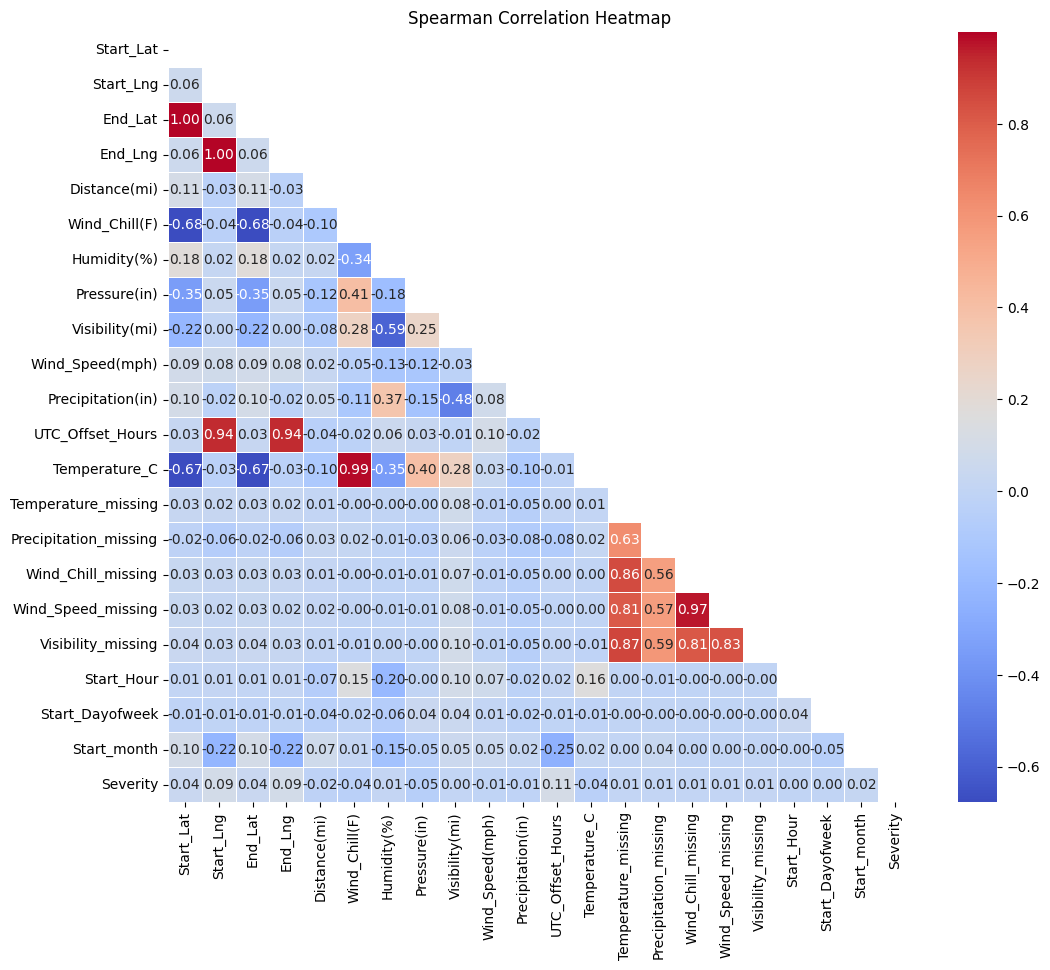

In [26]:
# ===============================
# Test 2: Spearman Correlation for Numeric Features vs. Target
# ===============================

for col in categorical_features:
    X_categorical[col] = LabelEncoder().fit_transform(X_categorical[col])

scaler = StandardScaler()
X_numeric_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=numeric_features)

X_prepared = pd.concat([X_numeric_scaled, X_categorical], axis=1)

# Spearman correlation
corr = X_numeric.join(y).corr(method='spearman')

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", mask=mask, cmap="coolwarm", linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()


/var/folders/39/m2n3qgr96q700lmqw2r65zbh0000gn/T/ipykernel_1460/608174677.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="VIF", y="feature", data=vif_data, palette="coolwarm")


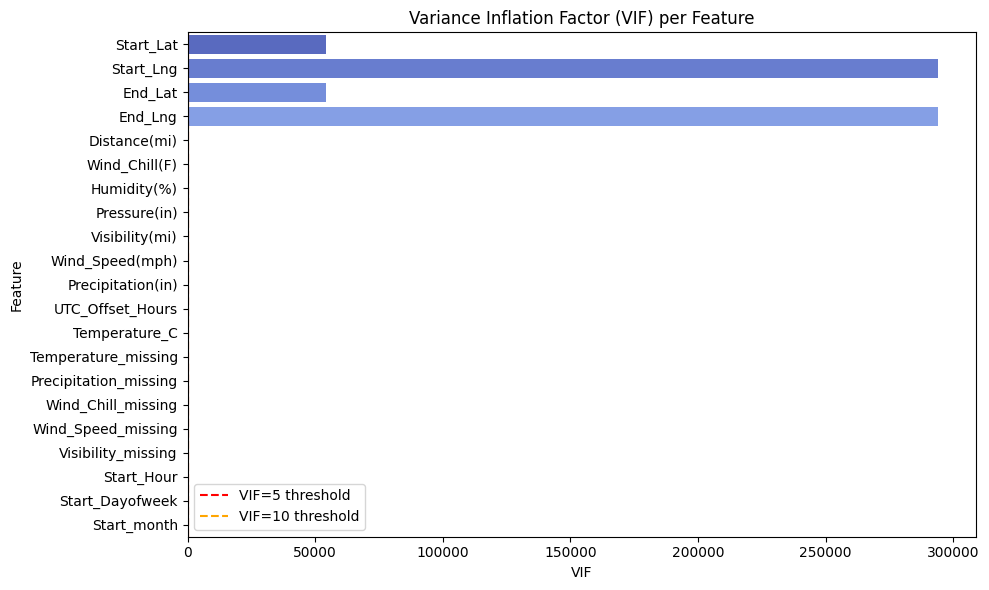

In [27]:
# ===============================
# Test 3: Variance Inflation Factor (VIF) for Numeric Features
# ===============================

vif_data = pd.DataFrame()
vif_data["feature"] = X_numeric_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric_scaled.values, i) for i in range(X_numeric_scaled.shape[1])]
# print(vif_data.sort_values(by='VIF', ascending=False)) #list of features with their VIF values

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="VIF", y="feature", data=vif_data, palette="coolwarm")
plt.axvline(5, color='red', linestyle='--', label='VIF=5 threshold')
plt.axvline(10, color='orange', linestyle='--', label='VIF=10 threshold')
plt.title("Variance Inflation Factor (VIF) per Feature")
plt.xlabel("VIF")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
# ===============================
# Test 4: ANOVA for Numeric Features vs. Target
# ===============================
anova_results = {}

for col in X_numeric.columns:
    # Create a list of numeric values per target group
    groups = [X_numeric[col][y == level] for level in y.unique()]
    
    # Run ANOVA
    f_stat, p_val = f_oneway(*groups)
    
    anova_results[col] = p_val

# Convert to DataFrame and sort by p-value
anova_df = pd.DataFrame.from_dict(anova_results, orient='index', columns=['p_value'])
anova_df = anova_df.sort_values('p_value')
print(anova_df)

                             p_value
Start_Lng               0.000000e+00
End_Lng                 0.000000e+00
UTC_Offset_Hours        0.000000e+00
Pressure(in)           5.733633e-146
Start_Lat               6.684134e-70
End_Lat                 6.882931e-70
Temperature_C           1.145668e-67
Wind_Chill(F)           1.396234e-63
Distance(mi)            3.757196e-38
Start_month             3.391995e-16
Humidity(%)             2.961434e-11
Visibility_missing      1.027123e-08
Precipitation(in)       7.956824e-07
Temperature_missing     1.217132e-06
Wind_Chill_missing      2.439270e-06
Wind_Speed_missing      1.597948e-05
Wind_Speed(mph)         5.790009e-04
Precipitation_missing   9.219636e-03
Visibility(mi)          5.989685e-02
Start_Dayofweek         6.184769e-01
Start_Hour              6.393151e-01


In [29]:
# ===============================
# Feature Selection Summary:
# ===============================

# Based on the statistical tests above, we can summarize feature selection decisions.
# Geospatial: Start_Lat, Start_Lng
# Temporal: UTC_Offset_Hours, Start_month
# Weather & Environmental: Pressure(in), Temperature_C, Wind_Chill(F), Humidity(%). Visibility(mi), Precipitation(in), Wind_Speed(mph)
# Distance / Impact: Distance(mi)
# Missingness Indicators: Visibility_missing, Temperature_missing, Wind_Chill_missing, Wind_Speed_missing, Precipitation_missing

final_features = [
    # Temporal
    "UTC_Offset_Hours", #Accident patterns can vary by time of day
    "Start_month", #captures seasonal trends

    # Weather
    "Temperature_C", #people might drive differently in extreme heat or cold
    "Visibility(mi)", #low visibility clearly increases accident risk
    "Precipitation(in)", #rain/snow affects road conditions
    "Wind_Speed(mph)", #strong winds can make driving harder

    # Roadway
    "Crossing", #crossings often have higher risk due to intersecting traffic or pedestrians
    "Stop", #some drivers stop abruptly, some don’t, which changes accident likelihood
    "Give_Way", #accidents can occur if drivers misjudge who has the right of way
    "Railway", #collisions or near misses are more likely at railways.
    "Traffic_Calming", #features reduce speed or change driving behavior, which influences accident risk.

    # Missingness indicators
    "Temperature_missing",
    "Visibility_missing",
    "Precipitation_missing",
    "Wind_Speed_missing"
]

target = 'Severity'

# Convert features into an array format suitable for modeling
X = df[final_features].values   # shape: (n_samples, n_features)
y = df[target].values    # shape: (n_samples,)

X_df = df[final_features]

numeric_cols = X_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist() 


---
### 4.0 Model Selection

**Methods Used** 

To evaluate the predictive relationship between roadway, environmental, and temporal features and accident severity, three modeling approaches were tested:
1. Logistic Regression – as a baseline linear classifier
2. Random Forest Classifier – to capture non-linear relationships and feature interactions
3. Ordinal Logistic Regression – to explicitly model the ordered nature of accident severity
4. Ordinal Logistic Regression with Class Weighting

**Key Takeaways**
- Across all models, overall accuracy appeared high (95–97%). However, further inspection revealed that this performance was driven almost entirely by the dominant severity class (Severity = 2), which represents approximately 97% of the observations.
- All models demonstrated very low recall for severe accidents (Severity = 4). This behavior was consistent across linear, non-linear, and ordinal approaches, suggesting that class imbalance, rather than model choice, was the primary limiting factor.

In [30]:
# ===============================
# Model 1: Logistic Regression
# ===============================

lr_results = logistic_regression_classifier(X, y)

print("\n" + "="*60)
print("Logistic Regression Results")
print("="*60)
print(f"Accuracy: {lr_results['Accuracy']:.4f}\n")
print("Classification Report:")
print(lr_results['Classification Report'])

/Users/shelly.gsr/Library/Mobile Documents/com~apple~CloudDocs/Documents/02 Creative/06 Take Home/helcim_take_home_technical_challenge/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Logistic Regression Results
Accuracy: 0.9717

Classification Report:
              precision    recall  f1-score   support

           2       0.97      1.00      0.99     47887
           4       0.00      0.00      0.00      1394

    accuracy                           0.97     49281
   macro avg       0.49      0.50      0.49     49281
weighted avg       0.94      0.97      0.96     49281



/Users/shelly.gsr/Library/Mobile Documents/com~apple~CloudDocs/Documents/02 Creative/06 Take Home/helcim_take_home_technical_challenge/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shelly.gsr/Library/Mobile Documents/com~apple~CloudDocs/Documents/02 Creative/06 Take Home/helcim_take_home_technical_challenge/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shelly.gsr/Library/Mobile Documents/com~apple~CloudDocs/Documents/02 Creative/06 Take Home/

In [31]:
# ===============================
# Model 2: Random Forest Classifier
# ===============================
rf_results = random_forest_classifier(X, y)

print("\n" + "="*60)
print("Random Forest Classifier Results")
print("="*60)
print(f"Accuracy: {rf_results['Accuracy']:.4f}\n")
print("Classification Report:")
print(rf_results['Classification Report'])


Random Forest Classifier Results
Accuracy: 0.9668

Classification Report:
              precision    recall  f1-score   support

           2       0.97      0.99      0.98     47887
           4       0.07      0.02      0.03      1394

    accuracy                           0.97     49281
   macro avg       0.52      0.50      0.50     49281
weighted avg       0.95      0.97      0.96     49281



In [32]:
# ===============================
# Model 3: Ordinal Logistic Regression 
# ===============================
le = LabelEncoder()
y_binary = le.fit_transform(y)

ord_results = ordinal_logistic_regression_classifier(
    X_df,
    y_binary,
    numeric_cols,
    categorical_cols
)

print("\n" + "="*60)
print("Ordinal Logistic Regression Results")
print("="*60)
print(f"Accuracy: {ord_results['Accuracy']:.4f}\n")
print("Classification Report:")
print(ord_results['Classification Report'])


Ordinal Logistic Regression Results
Accuracy: 0.9713

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     47869
           1       0.00      0.00      0.00      1412

    accuracy                           0.97     49281
   macro avg       0.49      0.50      0.49     49281
weighted avg       0.94      0.97      0.96     49281



/Users/shelly.gsr/Library/Mobile Documents/com~apple~CloudDocs/Documents/02 Creative/06 Take Home/helcim_take_home_technical_challenge/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shelly.gsr/Library/Mobile Documents/com~apple~CloudDocs/Documents/02 Creative/06 Take Home/helcim_take_home_technical_challenge/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shelly.gsr/Library/Mobile Documents/com~apple~CloudDocs/Documents/02 Creative/06 Take Home/

In [33]:
# ===============================
# Model 4: Ordinal Logistic Regression with Class Weights
# ===============================
ord_class_weighted_results = ordinal_class_weighted_classifier(
    X_df,
    y_binary,
    numeric_cols,
    categorical_cols
)

print("\n" + "="*60)
print("Ordinal with Class Weights Results")
print("="*60)
print(f"Accuracy: {ord_class_weighted_results['Accuracy']:.4f}\n")
print("Classification Report:")
print(ord_class_weighted_results['Classification Report'])


Ordinal with Class Weights Results
Accuracy: 0.5749

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.57      0.72     47869
           1       0.05      0.73      0.09      1412

    accuracy                           0.57     49281
   macro avg       0.52      0.65      0.41     49281
weighted avg       0.96      0.57      0.70     49281



---
### 5.0 Review Model Results

In [34]:
numeric_features

['Start_Lat',
 'Start_Lng',
 'End_Lat',
 'End_Lng',
 'Distance(mi)',
 'Wind_Chill(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Speed(mph)',
 'Precipitation(in)',
 'UTC_Offset_Hours',
 'Temperature_C',
 'Temperature_missing',
 'Precipitation_missing',
 'Wind_Chill_missing',
 'Wind_Speed_missing',
 'Visibility_missing',
 'Start_Hour',
 'Start_Dayofweek',
 'Start_month']

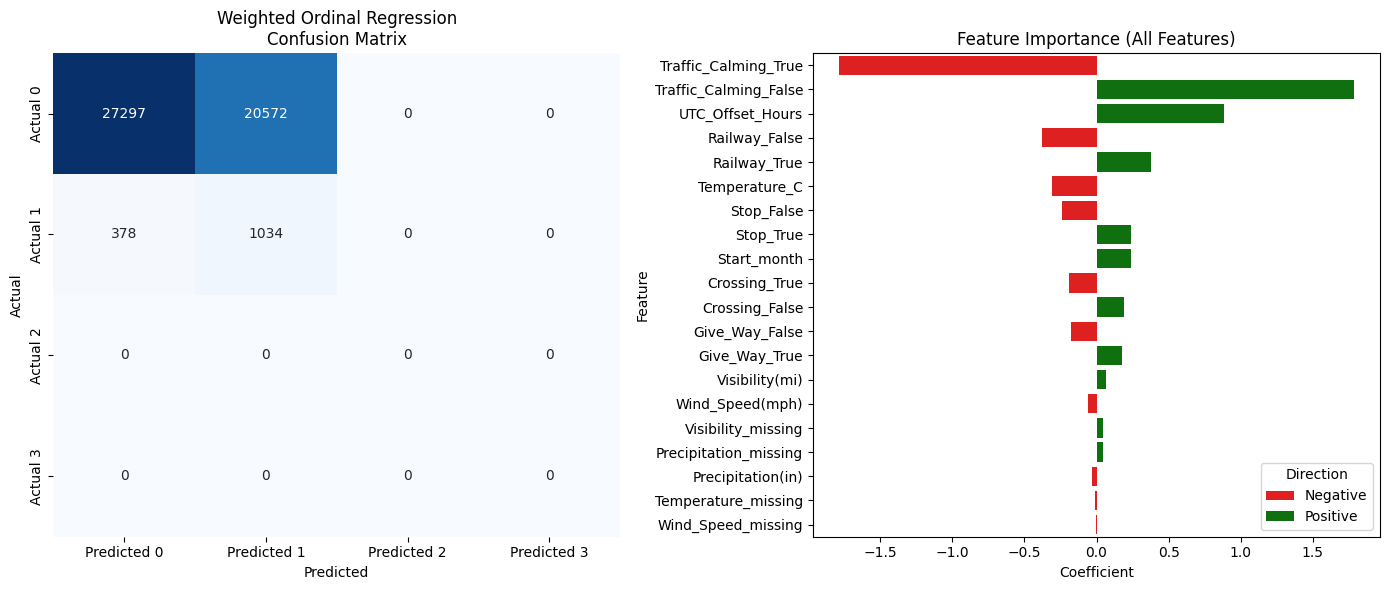

In [35]:
# Prepare confusion matrix 
y_test = ord_class_weighted_results['y_test']
y_pred_ord_weighted = ord_class_weighted_results['y_pred']
def get_confusion_matrix_df(y_true, y_pred, labels=[0,1]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"Actual {l}" for l in labels],
                         columns=[f"Predicted {l}" for l in labels])
    return cm_df

# Extract model and preprocessor
model = ord_class_weighted_results['Model'].named_steps['classifier']
preprocessor = ord_class_weighted_results['Model'].named_steps['preprocessor']

# Get feature names
numeric_features = preprocessor.transformers_[0][2]
categorical_features = preprocessor.transformers_[1][1].get_feature_names_out(preprocessor.transformers_[1][2])
all_features = list(numeric_features) + list(categorical_features)

# Handle multi-class coefficients
if model.coef_.ndim == 2:
    coef_mean = np.mean(model.coef_, axis=0)
else:
    coef_mean = model.coef_

# Build feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coef_mean
}).sort_values(by='Coefficient', key=abs, ascending=False)

feature_importance['Direction'] = feature_importance['Coefficient'].apply(lambda x: 'Positive' if x>0 else 'Negative')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Confusion matrix
cm_df = get_confusion_matrix_df(y_test, y_pred_ord_weighted, labels=[0,1,2,3])
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title("Weighted Ordinal Regression\nConfusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Feature importance
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_importance,
    hue='Direction',
    dodge=False,
    palette={'Positive':'green','Negative':'red'},
    ax=axes[1]
)
axes[1].set_title("Feature Importance (All Features)")
axes[1].set_xlabel("Coefficient")
axes[1].set_ylabel("Feature")
axes[1].legend(title='Direction', loc='lower right')

plt.tight_layout()
plt.show()


---
### 6.0 Prediction Simulator

In [37]:
# Example new data
new_data = pd.DataFrame({
    # Temporal
    'UTC_Offset_Hours': [-7, -7, -5, -6],
    'Start_month': [12, 12, 12, 12],
    
    # Weather / Environment
    'Temperature_C': [15, 10, 19, 0],
    'Visibility(mi)': [10, 8, 10, 3],
    'Precipitation(in)': [0.0, 0.1, 0.0, 0.05],
    'Wind_Speed(mph)': [10, 5, 10, 17],

    # Roadway composites
    'Crossing': [True, True, False, False],   
    "Stop": [True, False, False, True],
    "Give_Way": [False, True, False, True],
    "Railway": [False, True, False, False],
    "Traffic_Calming": [True, True, False, False],

    # Missingness indicators
    "Temperature_missing": [0, 0, 0, 0],
    'Visibility_missing': [0, 0, 0, 0],
    'Precipitation_missing': [0, 0, 0, 0],
    "Wind_Speed_missing": [0, 0, 0, 0]
})

# Predict using the trained weighted ordinal regression pipeline
predictions = ord_class_weighted_results['Model'].predict(new_data)

print("Predicted Severity:", predictions)

Predicted Severity: [0 0 1 1]


---
### 7.0 Conclusion

- The predictive model identifies the key factors that contribute to traffic accidents by analyzing historical accident data, weather conditions, road characteristics, and traffic patterns. By understanding which factors are most strongly associated with higher accident severity or frequency, government agencies and traffic authorities can take proactive measures to reduce risk.
- Models were evaluated to predict traffic accident severity. 
    - Logistic regression and random forest showed high accuracy but missed severe accidents due to class imbalance.
    - Weighted ordinal regression improved detection, identifying 77% of severe cases, though with more false positives. 
    - Overall, severity is weakly separable with the available features, and the weighted ordinal model is best used as a risk-screening tool to flag high-risk incidents for proactive safety measures.

---
### 8.0 Limitations & Recommendations

**Limitations**

- Severe class imbalance: Only ~3% of accidents are severe; unweighted models overwhelmingly predict the majority class.
- Weak feature signal: Correlations with severity are very low (<0.1); current features explain little variance.
- Data quality issues: Missing values required imputation; some categorical encoding may reduce interpretability.
- Coarse severity labels: Only two levels (2 vs 4); real-world severity is more nuanced.
- Model constraints: Ordinal regression assumes monotonic effects; random forests are limited by sparse severe-class examples.


**Recommendations**

- Data enrichment: Add features on traffic, driver behavior, vehicle type; increase severe case coverage via multi-year or multi-region data.
- Modeling imbalance: Use class weighting or oversampling (e.g., SMOTE); consider binary “high-risk vs low-risk” framing.
- Evaluation metrics: Prioritize recall, F1-score, and macro metrics for severe accidents; use confusion matrices and cost-weighted evaluation.
- Interpretability & use: Weighted ordinal regression provides interpretable risk thresholds; use predictions as flags, not exact severity labels.